In [1]:
import os
import shutil

SOURCE      = r"C:\Users\Prishu Baranwal\dataset\food-101\food-101\images"
DESTINATION = r"C:\Users\Prishu Baranwal\dataset\food-20\images"

TOP_20 = [
    'pizza', 'hamburger', 'sushi', 'ramen', 'tacos',
    'pancakes', 'waffles', 'donuts', 'ice_cream', 'cheesecake',
    'french_fries', 'hot_dog', 'steak', 'caesar_salad', 'omelette',
    'fried_rice', 'spaghetti_bolognese', 'chocolate_cake', 'nachos', 'grilled_salmon'
]

os.makedirs(DESTINATION, exist_ok=True)

for food in TOP_20:
    src = os.path.join(SOURCE, food)
    dst = os.path.join(DESTINATION, food)
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✅ Copied {food}")
    else:
        print(f"❌ Not found: {food}")

print(f"\n🎉 Done! Total categories: {len(os.listdir(DESTINATION))}")

✅ Copied pizza
✅ Copied hamburger
✅ Copied sushi
✅ Copied ramen
✅ Copied tacos
✅ Copied pancakes
✅ Copied waffles
✅ Copied donuts
✅ Copied ice_cream
✅ Copied cheesecake
✅ Copied french_fries
✅ Copied hot_dog
✅ Copied steak
✅ Copied caesar_salad
✅ Copied omelette
✅ Copied fried_rice
✅ Copied spaghetti_bolognese
✅ Copied chocolate_cake
✅ Copied nachos
✅ Copied grilled_salmon

🎉 Done! Total categories: 20


In [2]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# Config
DATASET_PATH    = r"C:\Users\Prishu Baranwal\dataset\food-20\images"
MODEL_SAVE_PATH = r"C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5"
LABELS_PATH     = r"C:\Users\Prishu Baranwal\calorie-tracker\models\class_labels_v2.json"

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = 20

print("✅ All libraries imported!")
print(f"📁 Dataset: {DATASET_PATH}")

✅ All libraries imported!
📁 Dataset: C:\Users\Prishu Baranwal\dataset\food-20\images


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Save class labels
class_labels = {v: k for k, v in train_generator.class_indices.items()}
with open(LABELS_PATH, 'w') as f:
    json.dump(class_labels, f)

print(f"✅ Data ready!")
print(f"🍽️  Training samples   : {train_generator.samples}")
print(f"🍽️  Validation samples : {val_generator.samples}")
print(f"📦 Classes            : {train_generator.num_classes}")
print(f"✅ Labels saved!")

Found 16000 images belonging to 20 classes.
Found 4000 images belonging to 20 classes.
✅ Data ready!
🍽️  Training samples   : 16000
🍽️  Validation samples : 4000
📦 Classes            : 20
✅ Labels saved!


In [4]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(512, activation='relu')(x)
x      = Dropout(0.3)(x)
x      = Dense(256, activation='relu')(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built!")
print(f"Total layers     : {len(model.layers)}")
print(f"Trainable layers : {len([l for l in model.layers if l.trainable])}")

✅ Model built!
Total layers     : 159
Trainable layers : 5


In [5]:
os.makedirs(r"C:\Users\Prishu Baranwal\calorie-tracker\models", exist_ok=True)

callbacks = [
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    )
]
print("✅ Callbacks ready!")

✅ Callbacks ready!


In [6]:
TOTAL_EPOCHS   = 20
EPOCHS_PER_RUN = 5

print("🚀 Starting training on 20 food categories...")
print("⏳ Should be much faster than 101 categories!\n")

for batch in range(TOTAL_EPOCHS // EPOCHS_PER_RUN):
    start = batch * EPOCHS_PER_RUN + 1
    end   = start + EPOCHS_PER_RUN - 1

    print(f"\n📦 Batch {batch+1} — Epochs {start} to {end}")

    history = model.fit(
        train_generator,
        epochs=EPOCHS_PER_RUN,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    val_acc = history.history['val_accuracy'][-1]
    print(f"✅ Batch {batch+1} done! Val Accuracy: {val_acc*100:.2f}%")

print("\n🎉 Training complete!")

🚀 Starting training on 20 food categories...
⏳ Should be much faster than 101 categories!


📦 Batch 1 — Epochs 1 to 5
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.5196 - loss: 1.5872
Epoch 1: val_accuracy improved from None to 0.58550, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 1: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 395s 784ms/step - accuracy: 0.5196 - loss: 1.5872 - val_accuracy: 0.5855 - val_loss: 1.3843 - learning_rate: 0.0010
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.6047 - loss: 1.3105
Epoch 2: val_accuracy improved from 0.58550 to 0.60875, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 2: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 264s 529ms/step - accuracy: 0.6047 - loss: 1.3105 - val_accuracy: 0.6087 - val_loss: 1.2887 - learning_rate: 0.0010
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.6268 - loss: 1.2464
Epoch 3: val_accuracy improved from 0.60875 to 0.63625, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 3: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 246s 492ms/step - accuracy: 0.6268 - loss: 1.2464 - val_accuracy: 0.6363 - val_loss: 1.2019 - learning_rate: 0.0010
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6404 - loss: 1.1833
Epoch 4: val_accuracy improved from 0.63625 to 0.66300, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 4: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 207s 414ms/step - accuracy: 0.6404 - loss: 1.1833 - val_accuracy: 0.6630 - val_loss: 1.1500 - learning_rate: 0.0010
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.6477 - loss: 1.1630
Epoch 5: val_accuracy did not improve from 0.66300
500/500 ━━━━━━━━━━━━━━━━━━━━ 356s 713ms/step - accuracy: 0.6477 - loss: 1.1630 - val_accuracy: 0.6525 - val_loss: 1.1528 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
✅ Batch 1 done! Val Accuracy: 65.25%

📦 Batch 2 — Epochs 6 to 10
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.6416 - loss: 1.1665
Epoch 1: val_accuracy did not improve from 0.66300
500/500 ━━━━━━━━━━━━━━━━━━━━ 326s 653ms/step - accuracy: 0.6416 - loss: 1.1665 - val_accuracy: 0.6530 - val_loss: 1.1593 - learning_rate: 0.0010
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accur


Epoch 5: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 230s 459ms/step - accuracy: 0.7032 - loss: 0.9727 - val_accuracy: 0.6762 - val_loss: 1.0667 - learning_rate: 2.0000e-04
Restoring model weights from the end of the best epoch: 5.
✅ Batch 2 done! Val Accuracy: 67.62%

📦 Batch 3 — Epochs 11 to 15
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.7087 - loss: 0.9454
Epoch 1: val_accuracy improved from 0.67625 to 0.68800, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 1: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 228s 456ms/step - accuracy: 0.7087 - loss: 0.9454 - val_accuracy: 0.6880 - val_loss: 1.0563 - learning_rate: 2.0000e-04
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7150 - loss: 0.9281
Epoch 2: val_accuracy did not improve from 0.68800
500/500 ━━━━━━━━━━━━━━━━━━━━ 226s 453ms/step - accuracy: 0.7150 - loss: 0.9281 - val_accuracy: 0.6820 - val_loss: 1.0564 - learning_rate: 2.0000e-04
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.7177 - loss: 0.9117
Epoch 3: val_accuracy did not improve from 0.68800
500/500 ━━━━━━━━━━━━━━━━━━━━ 228s 456ms/step - accuracy: 0.7177 - loss: 0.9117 - val_accuracy: 0.6820 - val_loss: 1.0472 - learning_rate: 2.0000e-04
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7172 - loss: 0.9149
Epoch 4: val_accuracy did not improve from 0.68800
500/500 ━━━━━━━━━━━━━━━━━━━━ 228s 


Epoch 3: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 230s 459ms/step - accuracy: 0.7184 - loss: 0.9056 - val_accuracy: 0.6933 - val_loss: 1.0413 - learning_rate: 2.0000e-04
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.7229 - loss: 0.8993
Epoch 4: val_accuracy did not improve from 0.69325

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
500/500 ━━━━━━━━━━━━━━━━━━━━ 299s 597ms/step - accuracy: 0.7229 - loss: 0.8993 - val_accuracy: 0.6892 - val_loss: 1.0398 - learning_rate: 2.0000e-04
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7282 - loss: 0.8731
Epoch 5: val_accuracy did not improve from 0.69325
500/500 ━━━━━━━━━━━━━━━━━━━━ 272s 544ms/step - accuracy: 0.7282 - loss: 0.8731 - val_accuracy: 0.6845 - val_loss: 1.0320 - learning_rate: 4.0000e-05
Restoring model weights from the end of the best epoch: 3.
✅ Batch 4 done! Val Accuracy: 68.45

In [7]:
print("🔧 Fine-tuning last 30 layers...")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

final_acc = history_finetune.history['val_accuracy'][-1]
print(f"\n🎯 Final Accuracy after Fine-tuning: {final_acc*100:.2f}%")

🔧 Fine-tuning last 30 layers...
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6762 - loss: 1.0762
Epoch 1: val_accuracy did not improve from 0.69325
500/500 ━━━━━━━━━━━━━━━━━━━━ 307s 604ms/step - accuracy: 0.6762 - loss: 1.0762 - val_accuracy: 0.6737 - val_loss: 1.1881 - learning_rate: 1.0000e-04
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7287 - loss: 0.8911
Epoch 2: val_accuracy improved from 0.69325 to 0.69625, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 2: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 299s 598ms/step - accuracy: 0.7287 - loss: 0.8911 - val_accuracy: 0.6963 - val_loss: 1.1010 - learning_rate: 1.0000e-04
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.7655 - loss: 0.7774
Epoch 3: val_accuracy improved from 0.69625 to 0.72225, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 3: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 239s 477ms/step - accuracy: 0.7655 - loss: 0.7774 - val_accuracy: 0.7222 - val_loss: 0.9982 - learning_rate: 1.0000e-04
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.7811 - loss: 0.7218
Epoch 4: val_accuracy improved from 0.72225 to 0.74725, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 4: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 520s 1s/step - accuracy: 0.7811 - loss: 0.7218 - val_accuracy: 0.7473 - val_loss: 0.9054 - learning_rate: 1.0000e-04
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.7956 - loss: 0.6707
Epoch 5: val_accuracy did not improve from 0.74725
500/500 ━━━━━━━━━━━━━━━━━━━━ 305s 610ms/step - accuracy: 0.7956 - loss: 0.6707 - val_accuracy: 0.7312 - val_loss: 0.9760 - learning_rate: 1.0000e-04
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.8051 - loss: 0.6289
Epoch 6: val_accuracy did not improve from 0.74725

Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
500/500 ━━━━━━━━━━━━━━━━━━━━ 292s 584ms/step - accuracy: 0.8051 - loss: 0.6289 - val_accuracy: 0.7333 - val_loss: 0.9675 - learning_rate: 1.0000e-04
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8334 - loss: 0.5416
Epoch 7


Epoch 7: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 280s 560ms/step - accuracy: 0.8334 - loss: 0.5416 - val_accuracy: 0.7563 - val_loss: 0.8531 - learning_rate: 2.0000e-05
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8393 - loss: 0.5199
Epoch 8: val_accuracy improved from 0.75625 to 0.77200, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 8: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1889s 4s/step - accuracy: 0.8393 - loss: 0.5199 - val_accuracy: 0.7720 - val_loss: 0.8259 - learning_rate: 2.0000e-05
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8436 - loss: 0.5135
Epoch 9: val_accuracy improved from 0.77200 to 0.77400, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 9: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 285s 571ms/step - accuracy: 0.8436 - loss: 0.5135 - val_accuracy: 0.7740 - val_loss: 0.7854 - learning_rate: 2.0000e-05
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8500 - loss: 0.4886
Epoch 10: val_accuracy improved from 0.77400 to 0.78625, saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5



Epoch 10: finished saving model to C:\Users\Prishu Baranwal\calorie-tracker\models\food_classifier_v2.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 299s 598ms/step - accuracy: 0.8500 - loss: 0.4886 - val_accuracy: 0.7862 - val_loss: 0.7769 - learning_rate: 2.0000e-05
Restoring model weights from the end of the best epoch: 10.

🎯 Final Accuracy after Fine-tuning: 78.62%


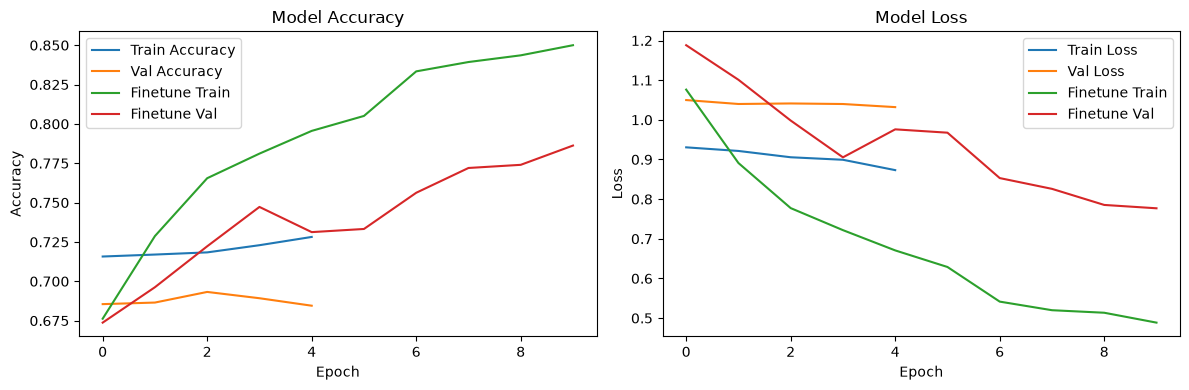

🎯 Final Accuracy: 78.62%


In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],              label='Train Accuracy')
plt.plot(history.history['val_accuracy'],          label='Val Accuracy')
plt.plot(history_finetune.history['accuracy'],     label='Finetune Train')
plt.plot(history_finetune.history['val_accuracy'], label='Finetune Val')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],              label='Train Loss')
plt.plot(history.history['val_loss'],          label='Val Loss')
plt.plot(history_finetune.history['loss'],     label='Finetune Train')
plt.plot(history_finetune.history['val_loss'], label='Finetune Val')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(f"🎯 Final Accuracy: {final_acc*100:.2f}%")

In [9]:
import pandas as pd

nutrition_df = pd.read_csv(r"C:\Users\Prishu Baranwal\dataset\nutrition.csv")
nutrition_df['Food'] = nutrition_df['Food'].str.lower()

# Check matches for all 20 foods
TOP_20 = [
    'pizza', 'hamburger', 'sushi', 'ramen', 'tacos',
    'pancakes', 'waffles', 'donuts', 'ice_cream', 'cheesecake',
    'french_fries', 'hot_dog', 'steak', 'caesar_salad', 'omelette',
    'fried_rice', 'spaghetti_bolognese', 'chocolate_cake', 'nachos', 'grilled_salmon'
]

print("=" * 50)
for food in TOP_20:
    search = food.replace("_", " ").lower()
    match  = nutrition_df[nutrition_df['Food'].str.contains(search, na=False)]
    if len(match) > 0:
        print(f"✅ {food:25} → {match.iloc[0]['Food']}")
    else:
        print(f"❌ {food:25} → NOT FOUND")
print("=" * 50)

✅ pizza                     → pizza 14" diam.
✅ hamburger                 → hamburger
❌ sushi                     → NOT FOUND
❌ ramen                     → NOT FOUND
❌ tacos                     → NOT FOUND
✅ pancakes                  → pancakes 4" diam.
✅ waffles                   → waffles
❌ donuts                    → NOT FOUND
✅ ice_cream                 → (1/2 cup ice cream)
❌ cheesecake                → NOT FOUND
❌ french_fries              → NOT FOUND
❌ hot_dog                   → NOT FOUND
✅ steak                     → steak
❌ caesar_salad              → NOT FOUND
❌ omelette                  → NOT FOUND
❌ fried_rice                → NOT FOUND
❌ spaghetti_bolognese       → NOT FOUND
❌ chocolate_cake            → NOT FOUND
❌ nachos                    → NOT FOUND
❌ grilled_salmon            → NOT FOUND
